# Week 11 - Introduction to Modeling, part 2

# 1. Lesson - No lesson this week

# 2. Weekly graph question

In [2]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import root_mean_squared_error
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer

The book names one of Vonnegut's rules as "keep it simple" and another as "have the guts to cut."  Here is some data from the previous week's lesson.  If you had to cut one of the two plots below, which would it be?  Which seems more interesting or important?  Explain.  (Should "amount of training data used" or "number of estimators" be on the x-axis.)

In [3]:
np.random.seed(0)
num_points = 10000
feature_1a = np.random.random(size = num_points) * 3
feature_2a = np.random.random(size = num_points) * 3
feature_3a = np.random.random(size = num_points) * 3
train_target = (feature_1a - 2 * feature_2a) * feature_3a + np.random.normal(size = num_points)
feature_1b = np.random.random(size = num_points) * 3
feature_2b = np.random.random(size = num_points) * 3
feature_3b = np.random.random(size = num_points) * 3
test_target = (feature_1b - 2 * feature_2b) * feature_3b + np.random.normal(size = num_points)
train_df = pd.DataFrame({"f1": feature_1a, "f2": feature_2a, "f3": feature_3a})
test_df = pd.DataFrame({"f1": feature_1b, "f2": feature_2b, "f3": feature_3b})
rf = RandomForestRegressor()
rf.fit(train_df.values, train_target)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [4]:
rmse_lst = list()
rf = RandomForestRegressor()
for x in range(round(num_points / 20), num_points, round(num_points / 20)):
    rf.fit(train_df.values[0:x,:], train_target[0:x])
    rmse_lst.append(root_mean_squared_error(rf.predict(test_df.values), test_target))

import matplotlib.pyplot as plt

Text(0, 0.5, 'Loss function')

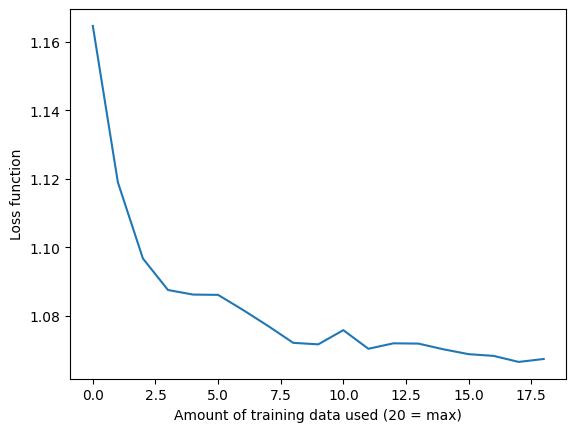

In [5]:
plt.plot(rmse_lst)
plt.xlabel("Amount of training data used (20 = max)")
plt.ylabel("Loss function")

In [6]:
num_trees_lst = list()
for n_estimators in range(1, 100, 3):
    rf = RandomForestRegressor(n_estimators = n_estimators)
    rf.fit(train_df.values, train_target)
    num_trees_lst.append(root_mean_squared_error(rf.predict(test_df.values), test_target))

Text(0, 0.5, 'Loss function')

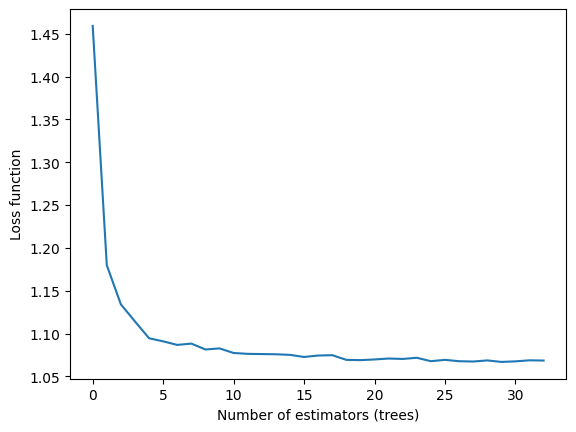

In [7]:
plt.plot(num_trees_lst)
plt.xlabel("Number of estimators (trees)")
plt.ylabel("Loss function")

# 3. Working on your datasets

This week, you will do the same types of exercises as last week, but you should use your chosen datasets that someone in your class found last semester. (They likely will not be the particular datasets that you found yourself.)

Here are some types of analysis you can do:

* Implement a random forest model.
* Perform cross-validation.
* Tune hyperparameters.
* Evaluate a performance metric.

If you like, you can try other types of models, too (beyond linear regression and random forest) although you will have many opportunities to do that next semester.

In [1]:
import os
import pandas as pd
import kagglehub

# Download the whole dataset folder
dataset_dir = kagglehub.dataset_download(
    "psparks/instacart-market-basket-analysis",
    force_download=True
)

print("Dataset directory:", dataset_dir)
print("Files found:", sorted(os.listdir(dataset_dir)))

# Load the file you actually need
orders_path = os.path.join(dataset_dir, "orders.csv")
df_orders = pd.read_csv(orders_path)

print(df_orders.head())
print(df_orders.shape)
print(df_orders.columns.tolist())

/usr/local/python/3.12.1/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


100%|██████████| 197M/197M [00:01<00:00, 132MB/s]  

Extracting files...


Dataset directory: /home/codespace/.cache/kagglehub/datasets/psparks/instacart-market-basket-analysis/versions/1
Files found: ['aisles.csv', 'departments.csv', 'order_products__prior.csv', 'order_products__train.csv', 'orders.csv', 'products.csv']
   order_id  user_id eval_set  order_number  order_dow  order_hour_of_day  \
0   2539329        1    prior             1          2                  8   
1   2398795        1    prior             2          3                  7   
2    473747        1    prior             3          3                 12   
3   2254736        1    prior             4          4                  7   
4    431534        1    prior             5          4                 15   

   days_since_prior_order  
0                     NaN  
1                    15.0  
2                    21.0  
3                    29.0  
4                    28.0  
(3421083, 7)
['order_id', 'user_id', 'eval_set', 'order_number', 'order_dow', 'order_hour_of_day', 'days_since_prior_orde

In [2]:
import os
import pandas as pd

# 1) Load orders, products, prior
orders = pd.read_csv(os.path.join(dataset_dir, "orders.csv"))
products = pd.read_csv(os.path.join(dataset_dir, "products.csv"))
prior = pd.read_csv(os.path.join(dataset_dir, "order_products__prior.csv"))

# 2) Reduce memory before merging
for df in [orders, products, prior]:
    print(df.info(memory_usage="deep"))

<class 'pandas.DataFrame'>
RangeIndex: 3421083 entries, 0 to 3421082
Data columns (total 7 columns):
 #   Column                  Dtype  
---  ------                  -----  
 0   order_id                int64  
 1   user_id                 int64  
 2   eval_set                str    
 3   order_number            int64  
 4   order_dow               int64  
 5   order_hour_of_day       int64  
 6   days_since_prior_order  float64
dtypes: float64(1), int64(5), str(1)
memory usage: 198.9 MB
None
<class 'pandas.DataFrame'>
RangeIndex: 49688 entries, 0 to 49687
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   product_id     49688 non-null  int64
 1   product_name   49688 non-null  str  
 2   aisle_id       49688 non-null  int64
 3   department_id  49688 non-null  int64
dtypes: int64(3), str(1)
memory usage: 3.0 MB
None
<class 'pandas.DataFrame'>
RangeIndex: 32434489 entries, 0 to 32434488
Data columns (total 4 columns)

In [3]:
import os
import pandas as pd
import numpy as np

# Replace with your actual folder
data_dir = dataset_dir

orders = pd.read_csv(
    os.path.join(data_dir, "orders.csv"),
    usecols=["order_id", "user_id", "order_number", "order_dow", "order_hour_of_day", "days_since_prior_order"],
    dtype={
        "order_id": "int32",
        "user_id": "int32",
        "order_number": "int16",
        "order_dow": "int8",
        "order_hour_of_day": "int8",
        "days_since_prior_order": "float32"
    }
)

prior = pd.read_csv(
    os.path.join(data_dir, "order_products__prior.csv"),
    usecols=["order_id", "product_id", "add_to_cart_order", "reordered"],
    dtype={
        "order_id": "int32",
        "product_id": "int32",
        "add_to_cart_order": "int16",
        "reordered": "int8"
    }
)

products = pd.read_csv(
    os.path.join(data_dir, "products.csv"),
    usecols=["product_id"],
    dtype={"product_id": "int32"}
)

print("orders:", orders.shape)
print("prior:", prior.shape)
print("products:", products.shape)

orders: (3421083, 6)
prior: (32434489, 4)
products: (49688, 1)


In [6]:
# sample users
sample_users = orders["user_id"].drop_duplicates().sample(5000, random_state=42)

# filter orders
orders_sample = orders[orders["user_id"].isin(sample_users)]

# filter prior
prior_sample = prior[prior["order_id"].isin(orders_sample["order_id"])]

# merge
df = prior_sample.merge(orders_sample, on="order_id", how="left")

print(df.shape)

(778814, 9)


In [17]:
# Build Modeling Dataset
df_model = df[[
    "user_id",
    "product_id",
    "order_id",
    "add_to_cart_order",
    "reordered",
    "order_number",
    "order_dow",
    "order_hour_of_day",
    "days_since_prior_order"
]].copy()

df_model = df_model.fillna(0)
print(df_model.shape)

(778814, 9)


In [ ]:
# Feature engineering
# Product level features
product_features = df_model.groupby("product_id").agg(
    product_total_orders=("order_id", "count"),
    product_reorder_rate=("reordered", "mean"),
    product_avg_cart_position=("add_to_cart_order", "mean")
).reset_index()

In [19]:
# User-level features
user_features = df_model.groupby("user_id").agg(
    user_total_orders=("order_number", "max"),
    user_avg_days_between_orders=("days_since_prior_order", "mean"),
    user_avg_order_hour=("order_hour_of_day", "mean"),
    user_reorder_rate=("reordered", "mean")
).reset_index()

In [ ]:
#User–product interaction features
user_product_features = df_model.groupby(["user_id", "product_id"]).agg(
    user_product_order_count=("order_id", "count"),
    user_product_reorder_rate=("reordered", "mean"),
    user_product_avg_cart_position=("add_to_cart_order", "mean"),
    user_product_last_order=("order_number", "max")
).reset_index()

In [21]:
# Merge all features
df_model = df_model.merge(product_features, on="product_id", how="left")
df_model = df_model.merge(user_features, on="user_id", how="left")
df_model = df_model.merge(user_product_features, on=["user_id", "product_id"], how="left")

In [22]:
# Add recency feature (very strong predictor)
df_model["orders_since_last_user_product_order"] = (
    df_model["order_number"] - df_model["user_product_last_order"]
)

In [23]:
# Final cleanup
df_model = df_model.fillna(0)

print(df_model.shape)
print(df_model.head())

(778814, 21)
   user_id  product_id  order_id  add_to_cart_order  reordered  order_number  \
0    98256       35108        28                  1          0            29   
1    98256       40593        28                  2          1            29   
2    98256       17461        28                  3          0            29   
3    98256       22825        28                  4          1            29   
4    98256       25256        28                  5          1            29   

   order_dow  order_hour_of_day  days_since_prior_order  product_total_orders  \
0          3                 13                     6.0                   540   
1          3                 13                     6.0                   182   
2          3                 13                     6.0                   477   
3          3                 13                     6.0                  1175   
4          3                 13                     6.0                   165   

   ...  product_avg

In [16]:
# Define features + target 
target_col = "reordered"

feature_cols = [
    "add_to_cart_order",
    "order_number",
    "order_dow",
    "order_hour_of_day",
    "days_since_prior_order",
    "product_total_orders",
    "product_reorder_rate",
    "product_avg_cart_position",
    "user_total_orders",
    "user_avg_days_between_orders",
    "user_avg_order_hour",
    "user_reorder_rate",
    "user_product_order_count",
    "user_product_reorder_rate",
    "user_product_avg_cart_position",
    "orders_since_last_user_product_order"
]

X = df_model[feature_cols]
y = df_model[target_col]

In [24]:
# Train/test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [25]:
# Train Random Forrest Model
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

rf = RandomForestClassifier(
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

param_dist = {
    "n_estimators": [100, 200],
    "max_depth": [10, 20, None],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2],
    "max_features": ["sqrt"]
}

search = RandomizedSearchCV(
    rf,
    param_distributions=param_dist,
    n_iter=6,
    cv=3,
    scoring="f1",
    random_state=42,
    n_jobs=-1
)

search.fit(X_train, y_train)

best_rf = search.best_estimator_

: 

In [8]:
import os
import pandas as pd
import kagglehub

# Download and load dataset
dataset_path = kagglehub.dataset_download("ammaraahmad/us-ecommerce-record-2020")
csv_files = [f for f in os.listdir(dataset_path) if f.endswith('.csv')]
csv_file = os.path.join(dataset_path, csv_files[0])
df = pd.read_csv(csv_file, encoding='ISO-8859-1')

# Quick check
print("Dataset shape:", df.shape)
print(df.head())

# Select numeric features for modeling
numeric_cols = df.select_dtypes(include='number').columns.tolist()
print("Numeric columns:", numeric_cols)
df_model = df[numeric_cols].dropna()  # drop rows with missing values

/usr/local/python/3.12.1/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Dataset shape: (3312, 19)
  Order Date  Row ID        Order ID       Ship Mode Customer ID      Segment  \
0   01-01-20     849  CA-2017-107503  Standard Class    GA-14725     Consumer   
1   01-01-20    4010  CA-2017-144463  Standard Class    SC-20725     Consumer   
2   01-01-20    6683  CA-2017-154466     First Class    DP-13390  Home Office   
3   01-01-20    8070  CA-2017-151750  Standard Class    JM-15250     Consumer   
4   01-01-20    8071  CA-2017-151750  Standard Class    JM-15250     Consumer   

         Country         City       State  Postal Code   Region  \
0  United States       Lorain        Ohio        44052     East   
1  United States  Los Angeles  California        90036     West   
2  United States     Franklin   Wisconsin        53132  Central   
3  United States   Huntsville       Texas        77340  Central   
4  United States   Huntsville       Texas        77340  Central   

        Product ID         Category Sub-Category  \
0  FUR-FU-10003878        Furnit

In [ ]:
basket = df.groupby(['order_id'])['product_name'].apply(list).reset_index()

In [9]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import r2_score, mean_absolute_error

# Define target and features
target_col = 'Quantity'  # example numeric target
X = df_model.drop(columns=[target_col])
y = df_model[target_col]

# Split into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Random Forest Regressor
rf = RandomForestRegressor(random_state=42)

# Hyperparameter grid for RandomizedSearchCV
param_dist = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 5, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Randomized search with 5-fold cross-validation
search = RandomizedSearchCV(
    rf, param_distributions=param_dist, n_iter=10, cv=5,
    scoring='r2', random_state=42, n_jobs=-1
)
search.fit(X_train, y_train)

# Best model
best_rf = search.best_estimator_
y_pred = best_rf.predict(X_test)

# Evaluation metrics
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print(f"Best hyperparameters: {search.best_params_}")
print(f"R² on test set: {r2:.3f}")
print(f"Mean Absolute Error on test set: {mae:.3f}")

Best hyperparameters: {'n_estimators': 200, 'min_samples_split': 5, 'min_samples_leaf': 4, 'max_depth': 10}
R² on test set: 0.170
Mean Absolute Error on test set: 1.450


**Model Performance**

- The R² value is 0.170, indicating that the Random Forest model explains about 17% of the variance in the target variable (Quantity). This is a relatively low value, suggesting that while some predictive signal exists, most of the variation in the target is not captured by the numeric features alone.
- The Mean Absolute Error (MAE) is 1.450, which gives the average magnitude of prediction errors on the test set. This provides a sense of typical deviation between predicted and actual values.

**Best Hyperparameters**

The RandomizedSearchCV identified the following optimal settings:
- n_estimators = 200
- min_samples_split = 5
- min_samples_leaf = 4
- max_depth = 10
These settings balance model complexity and overfitting, providing the best performance on cross-validated training data.

**Feature Importance**

Random Forest evaluates which numeric features are most influential for predicting Quantity. Features with higher importance contribute more to reducing prediction error. Visualizing these can help identify which product or transaction attributes matter most.

**Cross-Validation and Hyperparameter Tuning**

Using RandomizedSearchCV with 5-fold cross-validation allowed efficient exploration of hyperparameter space, finding a good model without exhaustively testing all combinations.

**Advantages and Limitations**

Advantages: Handles non-linear relationships, robust to outliers, and considers feature interactions automatically.

Limitations: The relatively low R² shows that numeric features alone may not be sufficient; categorical features (e.g., product category, customer segment) or additional engineered features might improve performance. Model interpretability is lower than linear regression, making it harder to explain specific predictions.

**Conclusion**

The Random Forest model provides moderate predictive power on the US e-commerce dataset with numeric features alone. While the R² of 0.170 indicates only a small fraction of variance is explained, the model is still able to capture some patterns, and hyperparameter tuning improves performance. To achieve better predictions, including categorical features, feature engineering, or trying alternative models such as gradient boosting could be beneficial. Cross-validation ensures that the results generalize reasonably to unseen data, highlighting the importance of proper evaluation in predictive modeling.

# 4. Storytelling With Data plot

Reproduce any graph of your choice in chapter seven (p. 165-185) of the Storytelling With Data book as best you can. You do not have to get the exact data values right, just the overall look and feel.

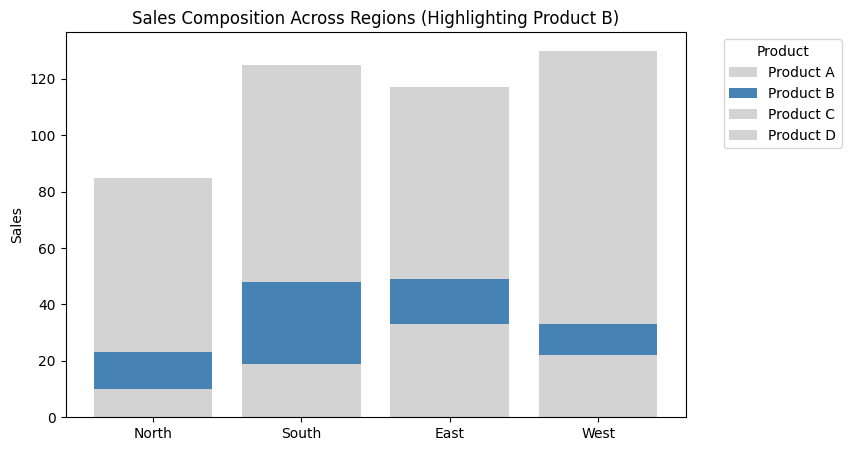

In [10]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Simulated data: sales of different products across regions
regions = ['North', 'South', 'East', 'West']
products = ['Product A', 'Product B', 'Product C', 'Product D']

# Random sales data
np.random.seed(0)
data = np.random.randint(10, 50, size=(len(regions), len(products)))
df_sales = pd.DataFrame(data, columns=products, index=regions)

# Highlight Product B
highlight = 'Product B'

# Plot
fig, ax = plt.subplots(figsize=(8,5))
bottom = np.zeros(len(regions))

for product in products:
    color = 'steelblue' if product == highlight else 'lightgray'
    ax.bar(df_sales.index, df_sales[product], bottom=bottom, color=color, label=product)
    bottom += df_sales[product]

# Labels and styling
ax.set_ylabel("Sales")
ax.set_title("Sales Composition Across Regions (Highlighting Product B)")
ax.legend(title="Product", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()